# Theo dõi giao thông Hà Nội từ YouTube (không tải video)

Notebook đọc luồng YouTube qua URL phát trực tiếp do `yt-dlp` phân giải (không ghi/tải video về đĩa), lọc ROI lòng đường, nhận diện + theo dõi phương tiện bằng YOLO11m/OpenVINO, rồi lưu liên tục các ảnh đã xử lý vào `img_outputs/`.

**Lưu ý hiệu năng:** YOLO11m chạy CPU là luồng xử lý chính. Cấu hình mặc định suy luận mỗi 2 frame, dùng ByteTrack cho các frame xen kẽ và giới hạn 720p; đây là cách thực tế để mục tiêu khoảng 30 FPS trên i5-12400F. Hãy chạy cell benchmark để kiểm chứng và tăng `DETECT_EVERY_N` nếu FPS chưa đạt.

In [1]:
# Cài một lần trong môi trường Python của notebook. Không tải video.
%pip install -q "ultralytics>=8.3" "openvino>=2024.0" yt-dlp opencv-python pandas
# Nếu OpenCV không mở được cửa sổ chọn ROI, cài bản không-headless: opencv-python (đã có ở trên).

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [58]:
from pathlib import Path
import json, time, math, shutil, subprocess
from collections import Counter, deque
import cv2
import numpy as np
import pandas as pd
from ultralytics import YOLO
from ultralytics.trackers.byte_tracker import BYTETracker
from ultralytics.utils import IterableSimpleNamespace

ROOT = Path.cwd()
MODEL_PT = ROOT / 'yolo11m.pt'
MODEL_OV = ROOT / 'yolo11m_openvino_model'
OUTPUT_DIR = ROOT / 'img_outputs'
OUTPUT_DIR.mkdir(exist_ok=True)

# Điền URL YouTube camera/video công khai. yt-dlp chỉ lấy URL stream tạm thời, không download.
YOUTUBE_URL = 'https://www.youtube.com/watch?v=CtTyYVHlkiU'
START_SEC = 1137       # x giây
END_SEC = 1165       # y giây; None để chạy tới cuối/live liên tục

# Tối ưu CPU i5-12400F: infer 720p, OpenVINO CPU, ByteTrack giữa các lần detect.
INFER_IMGSZ = 640
CONF = 0.30
IOU = 0.50
DETECT_EVERY_N = 2  # 2 = suy luận 15 lần/s với stream 30 FPS; tracker cập nhật 30 lần/s
SAVE_EVERY_N = 1    # 1 = lưu mọi frame đã xử lý; tăng nếu ổ cứng không theo kịp
MAX_FPS = 30

# Các class COCO cần thống kê. truck được gộp vào ô tô để số liệu giao thông hữu ích hơn.
VEHICLE_CLASSES = {2: 'oto', 3: 'xe_may', 5: 'xe_buyt', 1: 'xe_dap', 7: 'oto'}
VN_LABELS = {'oto': 'Ô tô', 'xe_may': 'Xe máy', 'xe_buyt': 'Xe buýt', 'xe_dap': 'Xe đạp'}

# Hiệu chuẩn tốc độ đơn giản: chỉnh theo cảnh sau khi biết khoảng cách thực tế.
METERS_PER_PIXEL = 0.035
SPEED_SMOOTHING = 12

assert MODEL_PT.exists() or MODEL_OV.exists(), 'Đặt yolo11m.pt vào thư mục dự án trước.'
print(f'Output: {OUTPUT_DIR.resolve()}')

Output: C:\Users\ADMIN\Downloads\traffic congestion detection\img_outputs


In [60]:
# Chuyển YOLO11m sang OpenVINO một lần (bỏ qua nếu thư mục model đã tồn tại).
# OpenVINO CPU là thiết bị chính. INT8 có thể nhanh hơn, nhưng cần calibration data để giữ độ chính xác.
if not MODEL_OV.exists():
    if not MODEL_PT.exists():
        raise FileNotFoundError(MODEL_PT)
    YOLO(MODEL_PT).export(format='openvino', imgsz=INFER_IMGSZ, dynamic=False, half=False)

model = YOLO(MODEL_OV if MODEL_OV.exists() else MODEL_PT, task='detect')
print('Inference backend:', MODEL_OV if MODEL_OV.exists() else MODEL_PT)
# device='cpu' trong model(...) ở dưới: CPU luôn là inference chính.

Inference backend: c:\Users\ADMIN\Downloads\traffic congestion detection\yolo11m_openvino_model


In [61]:
from yt_dlp import YoutubeDL


def youtube_stream_url(youtube_url: str) -> str:
    """Lấy URL media tạm thời, không tải video về đĩa."""
    options = {
        'quiet': True,
        'no_warnings': True,
        'noplaylist': True,
    }
    try:
        with YoutubeDL(options) as ydl:
            info = ydl.extract_info(youtube_url, download=False)
    except Exception as exc:
        raise RuntimeError(f'Không phân giải được YouTube URL: {exc}') from exc

    formats = [
        item for item in info.get('formats', [])
        if item.get('url') and item.get('vcodec') != 'none'
    ]
    if not formats:
        raise RuntimeError('Video không có format video mà yt-dlp có thể đọc.')

    # Một số video không cung cấp đúng format mp4/1080p; chọn format video gần nhất.
    bounded = [item for item in formats if item.get('height') and item['height'] <= 1080]
    candidates = bounded or formats
    selected = max(candidates, key=lambda item: (item.get('height') or 0, item.get('tbr') or 0))
    print(f"YouTube format: {selected.get('format_id')} | {selected.get('height') or '?'}p | {selected.get('ext', '?')}")
    return selected['url']


def open_youtube_capture(youtube_url: str):
    stream_url = youtube_stream_url(youtube_url)
    cap = cv2.VideoCapture(stream_url, cv2.CAP_FFMPEG)
    if not cap.isOpened():
        raise RuntimeError('OpenCV không mở được stream; thử cập nhật yt-dlp hoặc FFmpeg.')
    return cap


cap = open_youtube_capture(YOUTUBE_URL)
fps_input = cap.get(cv2.CAP_PROP_FPS) or 30.0
is_seekable = cap.get(cv2.CAP_PROP_FRAME_COUNT) > 0
if START_SEC and is_seekable:
    cap.set(cv2.CAP_PROP_POS_MSEC, START_SEC * 1000)
elif START_SEC:
    # Stream không seek được: bỏ frame đến mốc x tính từ lúc kết nối.
    for _ in range(int(START_SEC * fps_input)):
        if not cap.grab():
            break
ok, first_frame = cap.read()
if not ok:
    raise RuntimeError('Không đọc được frame đầu tiên.')
print(f'Nguồn {fps_input:.2f} FPS | frame đầu: {first_frame.shape[1]}x{first_frame.shape[0]}')

YouTube format: 270 | 1080p | mp4
Nguồn 30.00 FPS | frame đầu: 1920x1080


## Vẽ ROI lòng đường
Chạy cell kế tiếp, click các đỉnh ROI theo chiều kim đồng hồ, rồi nhấn **Enter**. Chỉ vehicle có tâm đáy bounding box trong đa giác này mới được tính. Chạy lại cell khi đổi góc camera.

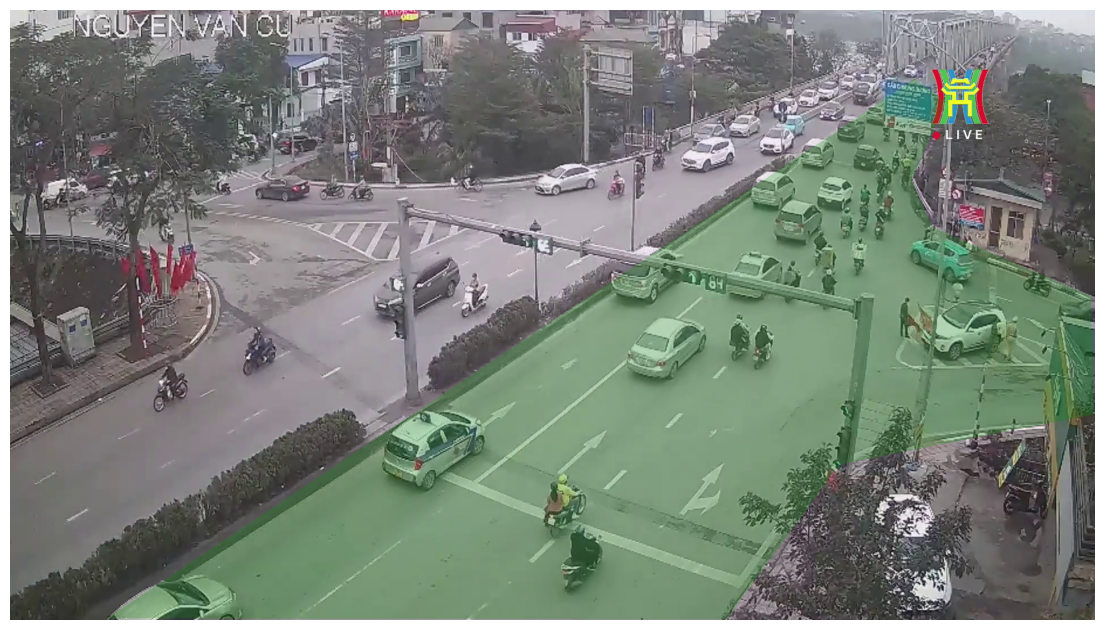

In [54]:
roi_points = []
canvas = first_frame.copy()
window = 'Click ROI road: Enter=done, r=reset, Esc=cancel'
def on_mouse(event, x, y, flags, param):
    global canvas, roi_points
    if event == cv2.EVENT_LBUTTONDOWN:
        roi_points.append((x, y))
        canvas = first_frame.copy()
        if len(roi_points) > 1: cv2.polylines(canvas, [np.array(roi_points)], False, (0, 255, 255), 2)
        for p in roi_points: cv2.circle(canvas, p, 5, (0, 255, 255), -1)
        cv2.imshow(window, canvas)

cv2.namedWindow(window, cv2.WINDOW_NORMAL)
cv2.setMouseCallback(window, on_mouse)
cv2.imshow(window, canvas)
while True:
    key = cv2.waitKey(20) & 0xFF
    if key == 13 and len(roi_points) >= 3: break
    if key in (ord('r'), ord('R')):
        roi_points, canvas = [], first_frame.copy(); cv2.imshow(window, canvas)
    if key == 27: raise RuntimeError('Đã hủy chọn ROI.')
cv2.destroyWindow(window)
ROI = np.array(roi_points, dtype=np.int32)
with open(ROOT / 'roi_hanoi_camera.json', 'w', encoding='utf-8') as f: json.dump(roi_points, f)
preview = first_frame.copy(); cv2.fillPoly(preview, [ROI], (0, 150, 0)); preview = cv2.addWeighted(preview, .25, first_frame, .75, 0)
import matplotlib.pyplot as plt
plt.figure(figsize=(14, 8)); plt.imshow(cv2.cvtColor(preview, cv2.COLOR_BGR2RGB)); plt.axis('off'); plt.show()

In [ ]:
# Tracker và các hàm thống kê / vẽ dashboard.
# Adapter này cho ByteTrack nhận các detection OpenVINO đã lọc ROI.
class Detections:
    def __init__(self, xyxy):
        self.xyxy = np.asarray(xyxy, dtype=np.float32).reshape(-1, 4)
        self.conf = np.empty(0, np.float32)
        self.cls = np.empty(0, np.float32)
        self.xywh = self.xyxy.copy()
    @classmethod
    def from_yolo(cls, rows):
        d = cls(rows[:, :4] if len(rows) else np.empty((0,4)))
        if len(rows):
            d.conf, d.cls = rows[:, 4], rows[:, 5]
            d.xywh[:, 2:] -= d.xywh[:, :2]  # ByteTrack cần x,y,w,h
        return d
    def __len__(self): return len(self.conf)
    def __getitem__(self, index):
        out = Detections(self.xyxy[index])
        out.conf, out.cls = np.atleast_1d(self.conf[index]), np.atleast_1d(self.cls[index])
        out.xywh = np.atleast_2d(self.xywh[index]).astype(np.float32)
        return out

tracker = BYTETracker(IterableSimpleNamespace(track_high_thresh=CONF, track_low_thresh=0.10, new_track_thresh=CONF, track_buffer=45, match_thresh=0.80, fuse_score=True))
track_history, known_kind = {}, {}
GRID_COLS, GRID_ROWS = 4, 3
STOP_SPEED_KMH = 8.0
STATE_SMOOTHING = 15

def in_roi(xyxy):
    x1, y1, x2, y2 = xyxy
    return cv2.pointPolygonTest(ROI, ((x1+x2)/2, y2), False) >= 0


def occupancy_from_boxes(boxes):
    """Tính occupancy bằng số ô lưới có xe, không cộng diện tích bounding box."""
    cells = set()
    for x1, y1, x2, y2 in boxes:
        cx, cy = (x1 + x2) / 2, y2
        if not in_roi((x1, y1, x2, y2)):
            continue
        col = min(GRID_COLS - 1, max(0, int((cx - roi_x) / max(roi_w, 1) * GRID_COLS)))
        row = min(GRID_ROWS - 1, max(0, int((cy - roi_y) / max(roi_h, 1) * GRID_ROWS)))
        cells.add((row, col))
    return len(cells) / (GRID_COLS * GRID_ROWS)


def traffic_state(vehicle_count, stopped_ratio, mean_speed, occupancy):
    """Phân loại trạng thái từ mức phủ ROI, xe dừng, tốc độ và số xe."""
    occupancy_score = min(1.0, occupancy / 0.50)
    count_score = min(1.0, vehicle_count / 12.0)
    speed_score = 1.0 - min(1.0, mean_speed / 35.0)
    congestion_score = (0.40 * occupancy_score + 0.35 * stopped_ratio +
                        0.15 * speed_score + 0.10 * count_score)
    if congestion_score >= 0.68:
        return 'Ùn tắc', congestion_score
    if congestion_score >= 0.40:
        return 'Đông', congestion_score
    return 'Thông thoáng', congestion_score


def dashboard(image, counts, avg_speed, density, state, elapsed, effective_fps):
    h, w = image.shape[:2]; panel_w = max(360, w // 3)
    panel = np.full((h, panel_w, 3), (24, 29, 37), np.uint8)
    lines = [('DỮ LIỆU GIAO THÔNG', (255,255,255)),
             *[(f'{VN_LABELS[k]}: {counts[k]}', (220,220,220)) for k in ['oto','xe_may','xe_buyt','xe_dap']],
             (f'Tốc độ TB: {avg_speed:.1f} km/h', (80,220,120)),
             (f'Chiếm dụng ROI: {density*100:.1f}%', (80,190,255)),
             (f'Trạng thái: {state}', (70,70,255) if state == 'Ùn tắc' else (80,220,120)),
             (f'T={elapsed:.1f}s | xử lý {effective_fps:.1f} FPS', (180,180,180))]
    y = 48
    for text, color in lines:
        cv2.putText(panel, text, (18, y), cv2.FONT_HERSHEY_SIMPLEX, .67, color, 2, cv2.LINE_AA); y += 42
    return np.hstack([image, panel])


In [ ]:
# Vòng xử lý: ảnh output_000001.jpg... được ghi liên tục, video nguồn không bao giờ được lưu.
# YOLO chỉ nhận vùng crop bao quanh ROI; output vẫn được vẽ trên toàn bộ frame gốc.
roi_x, roi_y, roi_w, roi_h = cv2.boundingRect(ROI)
roi_local = ROI - np.array([roi_x, roi_y], dtype=np.int32)
roi_mask = np.zeros((roi_h, roi_w), dtype=np.uint8)
cv2.fillPoly(roi_mask, [roi_local], 255)

frame_i, saved_i, processed_i = 0, 0, 0
last_detections = np.empty((0, 6), dtype=np.float32) # x1,y1,x2,y2,score,class, theo tọa độ frame gốc
state_scores = deque(maxlen=STATE_SMOOTHING)
started = time.perf_counter()
last_wall = started
frame = first_frame
try:
    while True:
        source_t = START_SEC + frame_i / fps_input
        if END_SEC is not None and source_t > END_SEC: break
        # Crop để giảm số pixel đưa vào YOLO; mask giữ đúng phần đa giác ROI.
        if frame_i % DETECT_EVERY_N == 0:
            roi_frame = frame[roi_y:roi_y + roi_h, roi_x:roi_x + roi_w].copy()
            roi_frame[roi_mask == 0] = 0
            result = model(roi_frame, imgsz=INFER_IMGSZ, conf=CONF, iou=IOU, device='cpu', verbose=False)[0]
            if result.boxes is not None and len(result.boxes):
                arr = result.boxes.data.cpu().numpy()
                translated = []
                for row in arr:
                    if int(row[5]) not in VEHICLE_CLASSES:
                        continue
                    box = row[:4].copy()
                    box[[0, 2]] += roi_x
                    box[[1, 3]] += roi_y
                    full_row = row.copy()
                    full_row[:4] = box
                    if in_roi(box):
                        translated.append(full_row)
                last_detections = np.asarray(translated, dtype=np.float32).reshape(-1, 6)
            else:
                last_detections = np.empty((0, 6), dtype=np.float32)
        tracks = tracker.update(Detections.from_yolo(last_detections), frame)
        annotated = frame.copy(); cv2.polylines(annotated, [ROI], True, (0,255,255), 2)
        counts, speeds, occupied_boxes = Counter(), [], []
        stopped_count, speed_count = 0, 0
        now = time.perf_counter()
        for tr in tracks:
            x1,y1,x2,y2,tid,score,cls,_ = tr
            kind = VEHICLE_CLASSES.get(int(cls)); box = [int(x1),int(y1),int(x2),int(y2)]
            if not kind or not in_roi(box): continue
            tid = int(tid); counts[kind] += 1; known_kind[tid] = kind
            occupied_boxes.append(box)
            cx, cy = (x1+x2)/2, y2; hist = track_history.setdefault(tid, deque(maxlen=SPEED_SMOOTHING))
            hist.append((cx, cy, now))
            speed = 0.0
            if len(hist) >= 2:
                ax, ay, at = hist[0]; bx, by, bt = hist[-1]; dt = bt-at
                if dt > 0:
                    speed = min(150., math.hypot(bx-ax, by-ay) * METERS_PER_PIXEL / dt * 3.6)
                    speeds.append(speed); speed_count += 1
                    stopped_count += speed <= STOP_SPEED_KMH
            color = {'oto':(0,200,0),'xe_may':(0,180,255),'xe_buyt':(255,80,40),'xe_dap':(255,0,255)}[kind]
            cv2.rectangle(annotated, (box[0],box[1]), (box[2],box[3]), color, 2)
            cv2.putText(annotated, f'{VN_LABELS[kind]} #{tid} {speed:.0f}km/h', (box[0], max(20,box[1]-7)), cv2.FONT_HERSHEY_SIMPLEX, .48, color, 2)
        density = occupancy_from_boxes(occupied_boxes)
        avg_speed = float(np.mean(speeds)) if speeds else 0.0
        stopped_ratio = stopped_count / speed_count if speed_count else 0.0
        raw_state, raw_score = traffic_state(sum(counts.values()), stopped_ratio, avg_speed, density)
        state_scores.append(raw_score)
        smooth_score = float(np.mean(state_scores))
        state = 'Ùn tắc' if smooth_score >= 0.68 else ('Đông' if smooth_score >= 0.40 else 'Thông thoáng')
        processed_i += 1; effective_fps = processed_i / max(now - started, 1e-6)
        composite = dashboard(annotated, counts, avg_speed, density, state, source_t, effective_fps)
        if frame_i % SAVE_EVERY_N == 0:
            cv2.imwrite(str(OUTPUT_DIR / f'output_{saved_i:06d}.jpg'), composite, [cv2.IMWRITE_JPEG_QUALITY, 92]); saved_i += 1
        # Giới hạn tốc độ xuất để không vượt mức mong muốn với file source.
        wait = max(0., 1/MAX_FPS - (time.perf_counter()-last_wall)); time.sleep(wait); last_wall = time.perf_counter()
        frame_i += 1
        ok, frame = cap.read()
        if not ok: break
finally:
    cap.release()
print(f'Đã xử lý {processed_i} frame, lưu {saved_i} ảnh vào: {OUTPUT_DIR}')

Loading c:\Users\ADMIN\Downloads\traffic congestion detection\yolo11m_openvino_model for OpenVINO inference...
Using OpenVINO LATENCY mode for batch=1 inference on CPU...


KeyboardInterrupt: 

In [ ]:
# Kiểm tra ảnh mới nhất ngay trong notebook.
from IPython.display import display, Image
latest = sorted(OUTPUT_DIR.glob('output_*.jpg'))[-1]
display(Image(filename=str(latest)))
print('Tinh chỉnh METERS_PER_PIXEL bằng một khoảng cách thật trên mặt đường để tốc độ chính xác hơn.')